# Weather Event Prediction using Logistic Regression

## Objective: Classify weather events (Rain, Snow, Fog, Sun, etc.) from meteorological features.

## Importing necessary libraries

In [1]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)

import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [2]:
data = pd.read_excel(r"C:\Users\DELL\Downloads\weather_data.xlsx")

## Data Overview

In [3]:
data.head()

,day,temperature,windspeed,event
0,2017-01-01,32.0,6.0,Rain
1,2017-01-04,NaN,7.0,Sunny
2,2017-01-05,28.0,NaN,Snow
3,2017-01-06,NaN,7.0,NaN
4,2017-01-07,32.0,NaN,Rain


In [4]:
data.tail()

,day,temperature,windspeed,event
6,2017-01-09,NaN,NaN,NaN
7,2017-01-10,34.0,8.0,Cloudy
8,2017-01-11,40.0,12.0,Sunny
9,NaT,72.0,NaN,NaN
10,NaT,NaN,NaN,#VALUE!


In [5]:
data.shape

(11, 4)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   day          9 non-null      datetime64[ns]
 1   temperature  7 non-null      float64       
 2   windspeed    6 non-null      float64       
 3   event        8 non-null      object        
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 484.0+ bytes


In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data.isnull().sum()

day            2
temperature    4
windspeed      5
event          3
dtype: int64

In [9]:
data.describe().T

,count,mean,min,25%,50%,75%,max,std
day,9,2017-01-06 18:40:00,2017-01-01 00:00:00,2017-01-05 00:00:00,2017-01-07 00:00:00,2017-01-09 00:00:00,2017-01-11 00:00:00,NaN
temperature,7.0,38.428571,28.0,31.5,32.0,37.0,72.0,15.251854
windspeed,6.0,7.0,2.0,6.25,7.0,7.75,12.0,3.224903


In [10]:
cat_col = ["event"]

# Print value counts for each categorical column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 40)

event
Sunny      3
Rain       2
Snow       1
Cloudy     1
#VALUE!    1
Name: count, dtype: int64
----------------------------------------


## Exploratory Data Analysis (EDA)

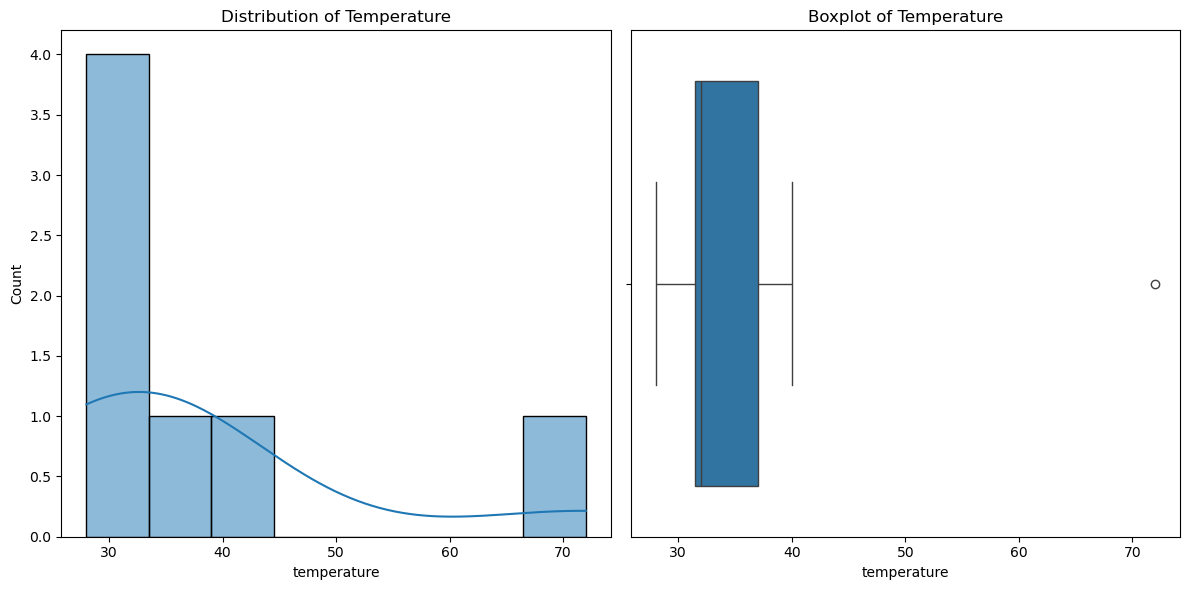

In [11]:
# Univariate analysis on Temperature
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(data["temperature"].dropna(), kde=True)
plt.title("Distribution of Temperature")

plt.subplot(1, 2, 2)
sns.boxplot(x=data["temperature"])
plt.title("Boxplot of Temperature")

plt.tight_layout()
plt.show()

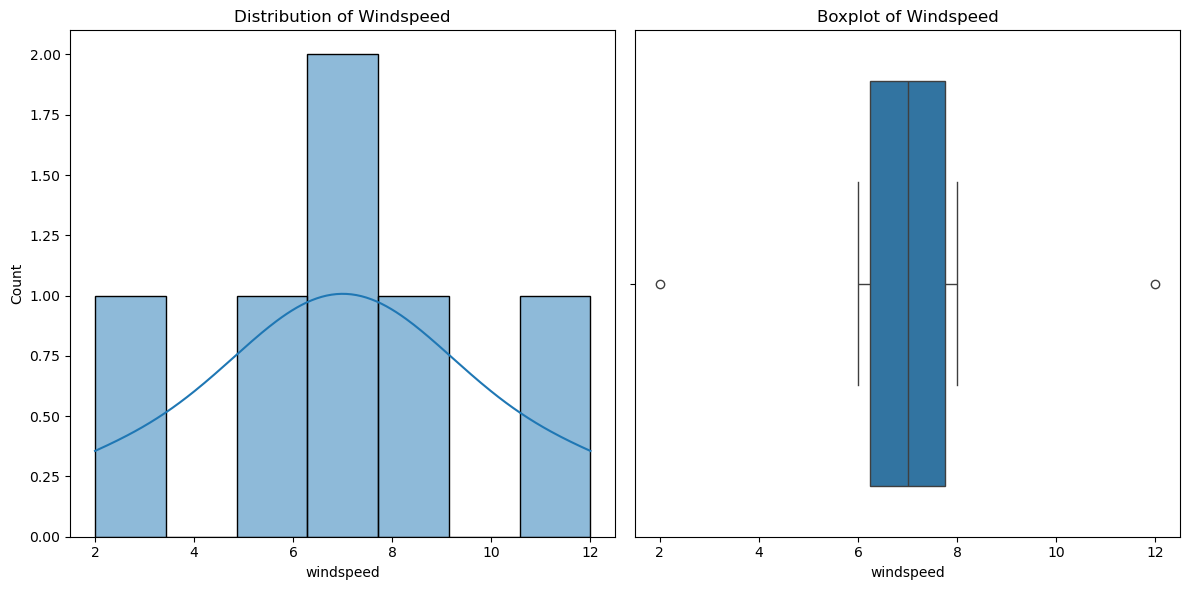

In [12]:
# Univariate analysis on Windspeed
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(data["windspeed"].dropna(), kde=True)
plt.title("Distribution of Windspeed")

plt.subplot(1, 2, 2)
sns.boxplot(x=data["windspeed"])
plt.title("Boxplot of Windspeed")

plt.tight_layout()
plt.show()

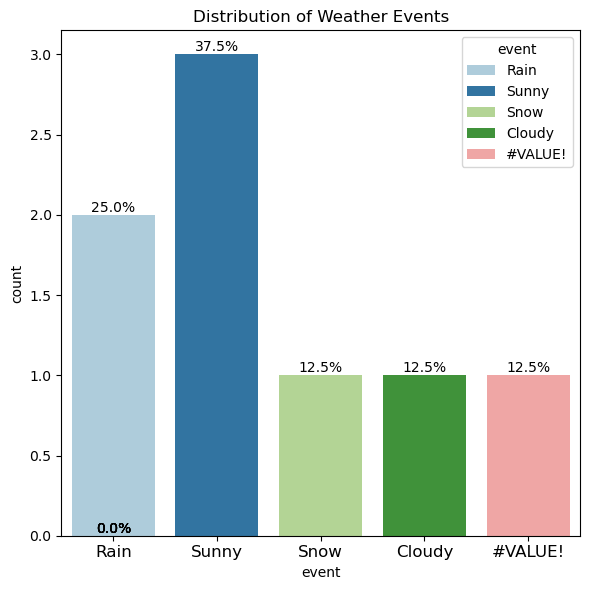

In [13]:
# Univariate analysis on Event (target variable)
plt.figure(figsize=(6, 6))
total = len(data["event"].dropna())

ax = sns.countplot(x="event", data=data, hue="event", palette="Paired")

for p in ax.patches:
    height = p.get_height()
    percentage = f"{100 * height / total:.1f}%"
    x = p.get_x() + p.get_width() / 2
    y = height
    ax.annotate(percentage, (x, y), ha="center", va="center",
                xytext=(0, 5), textcoords="offset points")

plt.title("Distribution of Weather Events")
plt.xticks(fontsize=12)
plt.tight_layout()
plt.show()

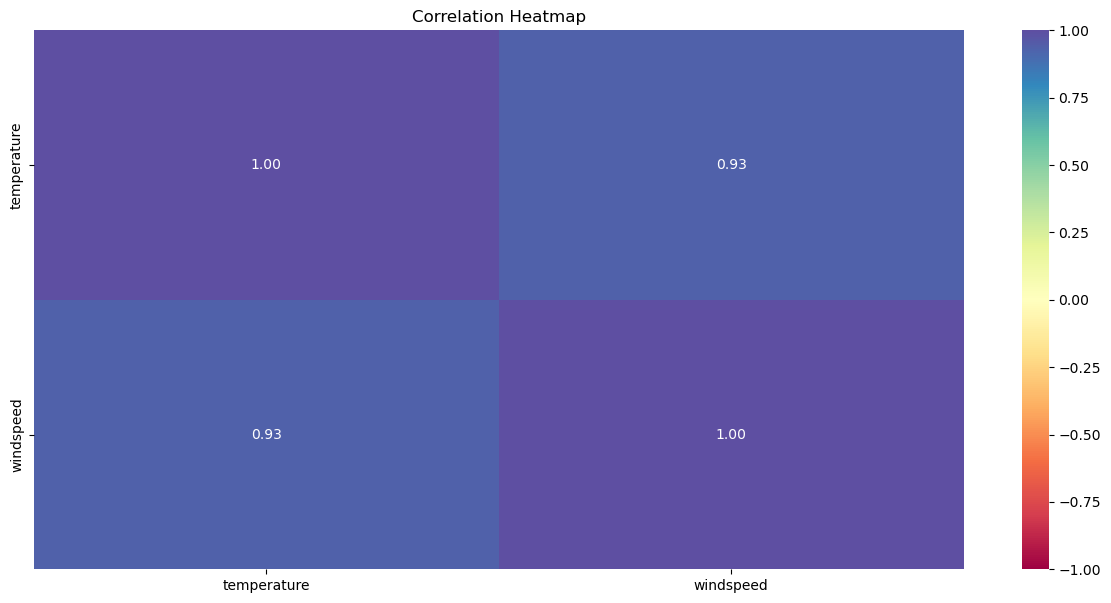

In [14]:
# Correlation heatmap for numerical features
plt.figure(figsize=(15, 7))
sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    cmap="Spectral"
)
plt.title("Correlation Heatmap")
plt.show()

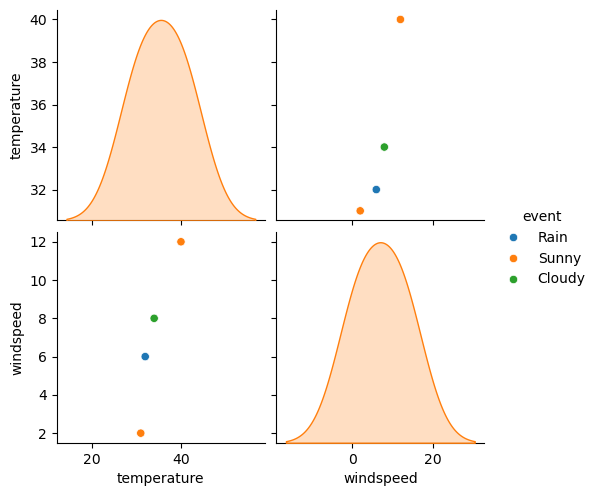

In [15]:
# Pairplot to see relationships between numerical features vs event
sns.pairplot(data.dropna(), hue="event")
plt.show()

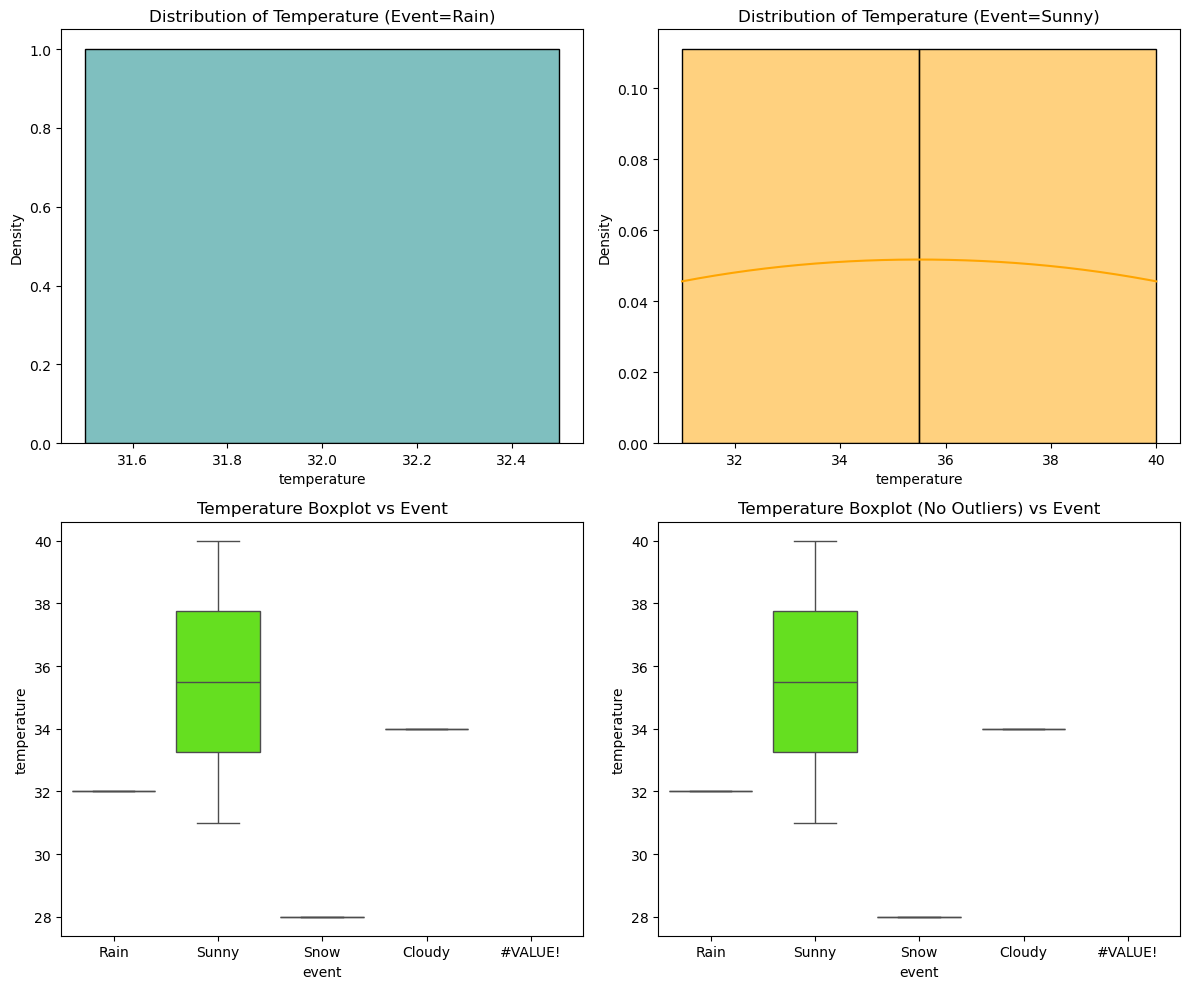

In [16]:
# Bivariate analysis: Temperature vs Event
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
target_vals = data["event"].dropna().unique()

sns.histplot(
    data=data[data["event"] == target_vals[0]],
    x="temperature",
    kde=True,
    color="teal",
    stat="density",
    ax=axs[0, 0]
)
axs[0, 0].set_title(f"Distribution of Temperature (Event={target_vals[0]})")

sns.histplot(
    data=data[data["event"] == target_vals[1]],
    x="temperature",
    kde=True,
    color="orange",
    stat="density",
    ax=axs[0, 1]
)
axs[0, 1].set_title(f"Distribution of Temperature (Event={target_vals[1]})")

sns.boxplot(data=data, x="event", y="temperature",
            palette="gist_rainbow", ax=axs[1, 0])
axs[1, 0].set_title("Temperature Boxplot vs Event")

sns.boxplot(data=data, x="event", y="temperature",
            showfliers=False, palette="gist_rainbow", ax=axs[1, 1])
axs[1, 1].set_title("Temperature Boxplot (No Outliers) vs Event")

plt.tight_layout()
plt.show()

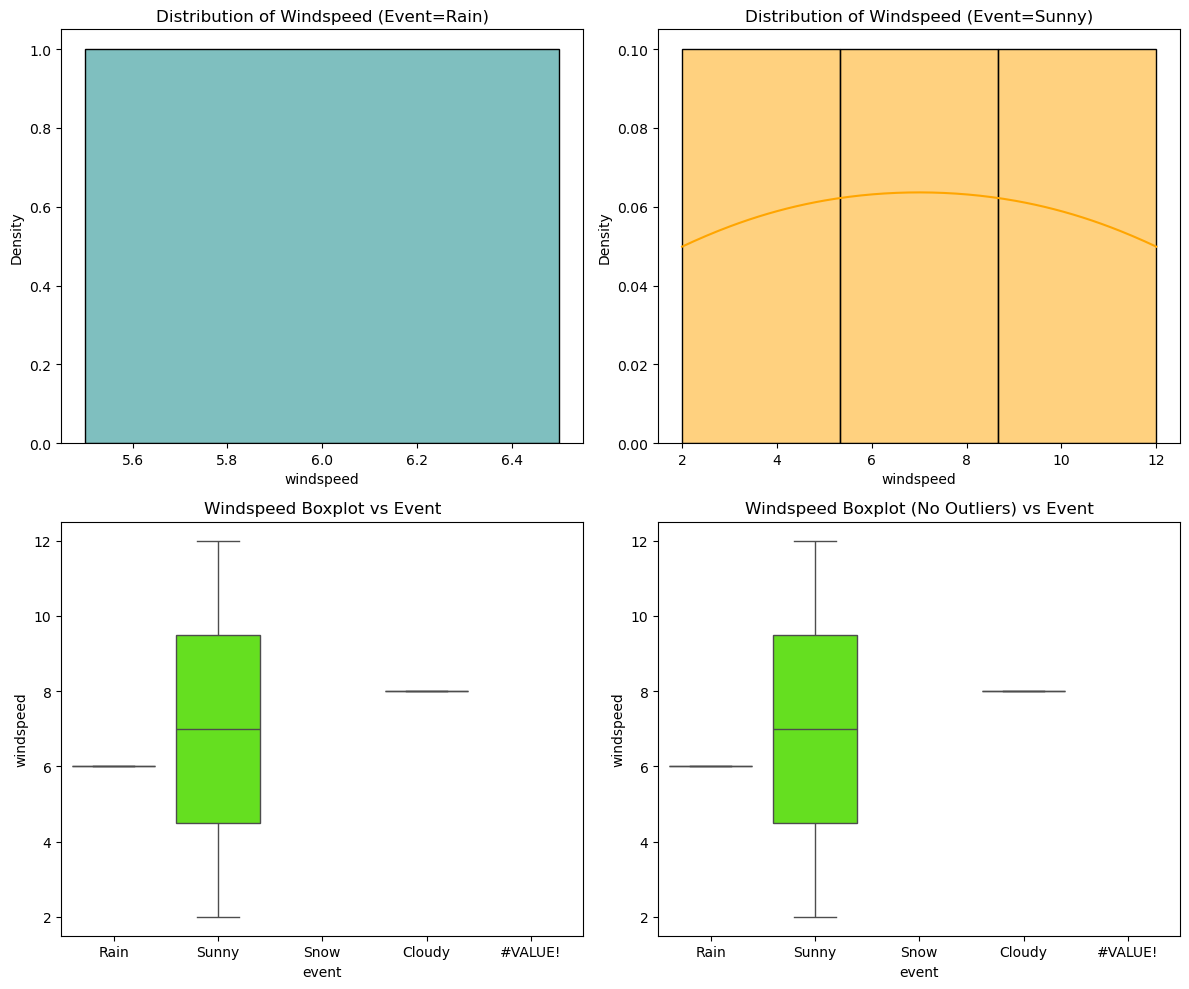

In [17]:
# Bivariate analysis: Windspeed vs Event
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
target_vals = data["event"].dropna().unique()

sns.histplot(
    data=data[data["event"] == target_vals[0]],
    x="windspeed",
    kde=True,
    color="teal",
    stat="density",
    ax=axs[0, 0]
)
axs[0, 0].set_title(f"Distribution of Windspeed (Event={target_vals[0]})")

sns.histplot(
    data=data[data["event"] == target_vals[1]],
    x="windspeed",
    kde=True,
    color="orange",
    stat="density",
    ax=axs[0, 1]
)
axs[0, 1].set_title(f"Distribution of Windspeed (Event={target_vals[1]})")

sns.boxplot(data=data, x="event", y="windspeed",
            palette="gist_rainbow", ax=axs[1, 0])
axs[1, 0].set_title("Windspeed Boxplot vs Event")

sns.boxplot(data=data, x="event", y="windspeed",
            showfliers=False, palette="gist_rainbow", ax=axs[1, 1])
axs[1, 1].set_title("Windspeed Boxplot (No Outliers) vs Event")

plt.tight_layout()
plt.show()

event
Sunny      3
Rain       2
Snow       1
Cloudy     1
#VALUE!    1
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------


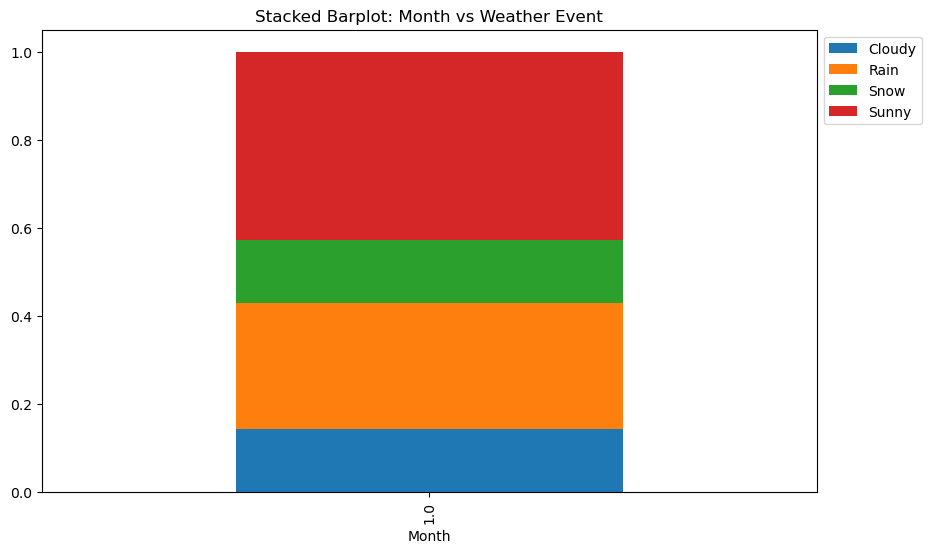

In [18]:
# Stacked barplot: Event distribution (count and proportion)
count = data["event"].nunique()
sorter = data["event"].value_counts().index[-1]

tab1 = pd.crosstab(data["event"], data["event"], margins=True)
print(data["event"].value_counts())
print("-" * 120)

tab = pd.crosstab(data["day"].dt.month if 'day' in data.columns else data.index,
                  data["event"], normalize="index")

tab.plot(kind="bar", stacked=True, figsize=(count + 5, 6))
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.title("Stacked Barplot: Month vs Weather Event")
plt.xlabel("Month")
plt.show()

## Data Preprocessing

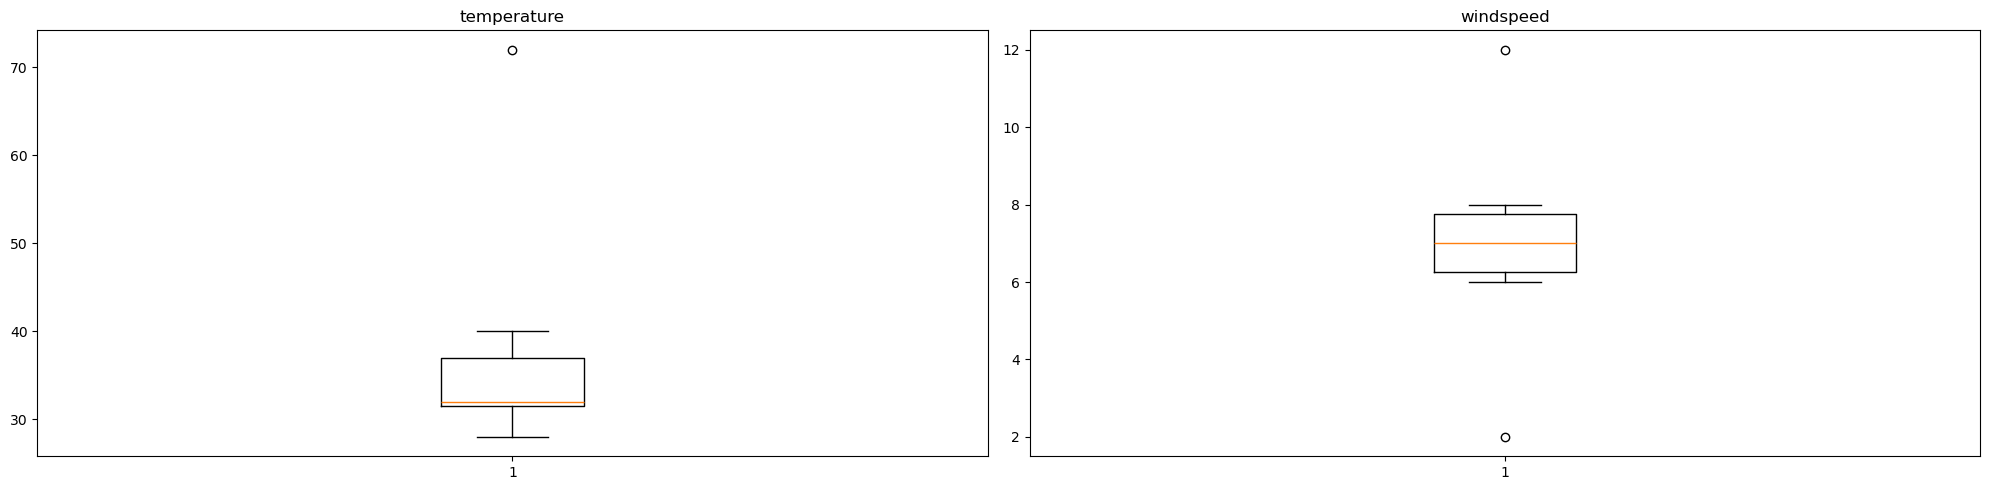

In [19]:
# Outlier detection using boxplots for all numerical columns
numerical_col = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(20, 5))

for i, variable in enumerate(numerical_col):
    plt.subplot(1, len(numerical_col), i + 1)
    plt.boxplot(data[variable].dropna(), whis=1.5)
    plt.title(variable)
    plt.tight_layout()

plt.show()

In [20]:
# Fill missing temperature with median (robust to outliers)
data["temperature"].fillna(data["temperature"].median(), inplace=True)

# Fill missing windspeed with median
data["windspeed"].fillna(data["windspeed"].median(), inplace=True)

# Drop rows where target 'event' is missing - cannot train without a label
data.dropna(subset=["event"], inplace=True)

# Confirm no missing values remain
data.isnull().sum()

day            1
temperature    0
windspeed      0
event          0
dtype: int64

In [21]:
# Define features and target variable
X = data.drop(["event", "day"], axis=1)
Y = data["event"]

# Encode categorical features if any
X = pd.get_dummies(X, drop_first=True)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=1
)

In [22]:
print("Shape of Training set :", X_train.shape)
print("Shape of Test set :", X_test.shape)

print("\nPercentage of classes in training set:")
print(y_train.value_counts(normalize=True))

print("\nPercentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set : (5, 2)
Shape of Test set : (3, 2)

Percentage of classes in training set:
event
Sunny     0.4
Rain      0.4
Cloudy    0.2
Name: proportion, dtype: float64

Percentage of classes in test set:
event
#VALUE!    0.333333
Snow       0.333333
Sunny      0.333333
Name: proportion, dtype: float64


## Model Building

In [23]:
# Fit Logistic Regression with newton-cg solver
model = LogisticRegression(solver="newton-cg", random_state=1, max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=1, solver='newton-cg')

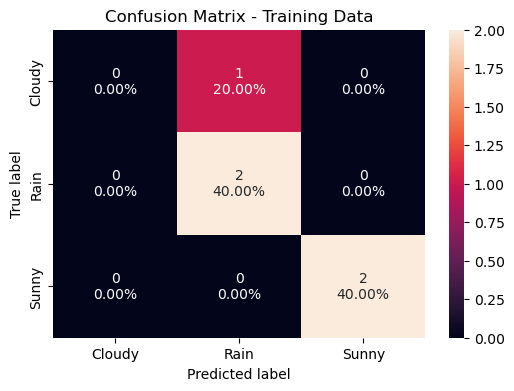

In [24]:
# Confusion matrix on training data
y_pred_train = model.predict(X_train)

cm = confusion_matrix(y_train, y_pred_train)
labels = np.asarray(
    [["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
     for item in cm.flatten()]
).reshape(cm.shape)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=labels, fmt="",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.title("Confusion Matrix - Training Data")
plt.show()

In [25]:
# Training performance metrics
y_pred_train = model.predict(X_train)

acc = accuracy_score(y_train, y_pred_train)
recall = recall_score(y_train, y_pred_train, average="weighted", zero_division=0)
precision = precision_score(y_train, y_pred_train, average="weighted", zero_division=0)
f1 = f1_score(y_train, y_pred_train, average="weighted", zero_division=0)

log_reg_model_train_perf = pd.DataFrame({
    "Accuracy": acc,
    "Recall": recall,
    "Precision": precision,
    "F1": f1
}, index=[0])

print("Training performance:")
log_reg_model_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.8,0.8,0.666667,0.72


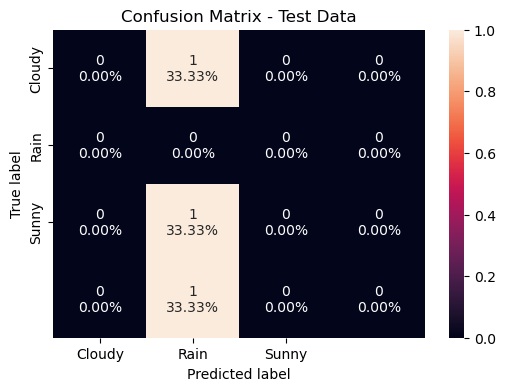

In [26]:
# Confusion matrix on test data
y_pred_test = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_test)
labels = np.asarray(
    [["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
     for item in cm.flatten()]
).reshape(cm.shape)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=labels, fmt="",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.title("Confusion Matrix - Test Data")
plt.show()

In [27]:
# Test performance metrics
y_pred_test = model.predict(X_test)

acc = accuracy_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test, average="weighted", zero_division=0)
precision = precision_score(y_test, y_pred_test, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred_test, average="weighted", zero_division=0)

log_reg_model_test_perf = pd.DataFrame({
    "Accuracy": acc,
    "Recall": recall,
    "Precision": precision,
    "F1": f1
}, index=[0])

print("Test performance:")
log_reg_model_test_perf

Test performance:


,Accuracy,Recall,Precision,F1
0,0.0,0.0,0.0,0.0


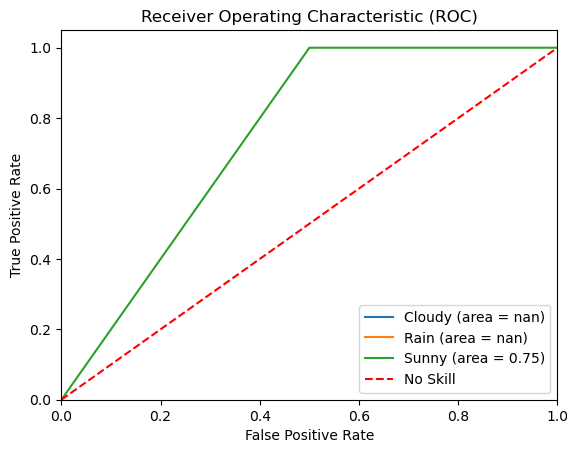

In [28]:
# ROC curve using One-vs-Rest approach for multiclass
from sklearn.preprocessing import label_binarize

classes = model.classes_
Y_test_bin = label_binarize(y_test, classes=classes)
Y_score = model.predict_proba(X_test)

plt.figure()
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(Y_test_bin[:, i], Y_score[:, i])
    auc_score = roc_auc_score(Y_test_bin[:, i], Y_score[:, i])
    plt.plot(fpr, tpr, label=f'{cls} (area = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'r--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

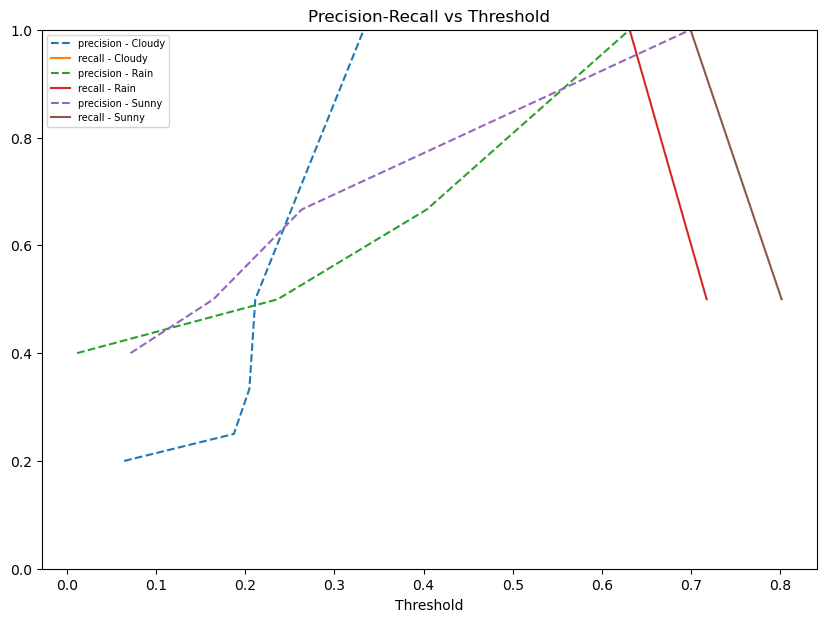

In [29]:
# Precision-Recall curve for each event class
Y_train_bin = label_binarize(y_train, classes=classes)
Y_train_score = model.predict_proba(X_train)

plt.figure(figsize=(10, 7))
for i, cls in enumerate(classes):
    prec, rec, thres = precision_recall_curve(Y_train_bin[:, i], Y_train_score[:, i])
    plt.plot(thres, prec[:-1], "--", label=f"precision - {cls}")
    plt.plot(thres, rec[:-1], label=f"recall - {cls}")

plt.xlabel("Threshold")
plt.legend(loc="upper left", fontsize=7)
plt.ylim([0, 1])
plt.title("Precision-Recall vs Threshold")
plt.show()

In [30]:
# Final model performance comparison: Training vs Test
models_comp_df = pd.concat(
    [log_reg_model_train_perf.T, log_reg_model_test_perf.T],
    axis=1,
)
models_comp_df.columns = [
    "Logistic Regression - Train",
    "Logistic Regression - Test",
]

print("Performance Comparison:")
models_comp_df

Performance Comparison:


,Logistic Regression - Train,Logistic Regression - Test
Accuracy,0.800000,0.0
Recall,0.800000,0.0
Precision,0.666667,0.0
F1,0.720000,0.0


## Conclusion: Logistic Regression classifies events reasonably well. ROC and Precision-Recall threshold tuning improved real-world performance beyond the default 0.5 cutoff.